# 08 — Brownain Motion close to the border

$
\Omega=\{x\leq 0,\ \|x\|\leq R\}.
$

## Temporal scaling

In [4]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from stage_escape import BrownianMotion, Escape, NaiveNarrowEscape, Surface

RUN_MODE = "full"       # "smoke", "full" o "load"
REUSE_CACHE = True
N_JOBS = -1
BASE_SEED = 20260805
SAVE_FIGURES = False

DIFFUSION = 1.0
OUTER_RADIUS = 1.0
START_DISTANCE_FACTOR = 1.0
SPATIAL_RESOLUTION = 0.20

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Ejecuta Jupyter dentro del repositorio STAGE.")

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_08"
FIGURE_DIR = ARTIFACT_DIR / "figures"
SUMMARY_PATH = ARTIFACT_DIR / f"border_probability_{RUN_MODE}.csv"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, filename: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

In [5]:
def half_ball_surface() -> Surface:
    return Surface(
        "half ball",
        [
            lambda point: float(point[0]),
            lambda point: float(np.dot(point, point) - OUTER_RADIUS**2),
        ],
    )

def target_window(epsilon: float) -> Escape:
    return Escape(
        [
            lambda point: bool(point[0] >= -1.0e-10),
            lambda point: bool(
                np.linalg.norm(np.asarray(point, dtype=float)[1:])
                <= epsilon + 1.0e-10
            ),
        ]
    )

def outer_escape() -> Escape:
    return Escape(
        [
            lambda point: bool(
                np.linalg.norm(np.asarray(point, dtype=float))
                >= OUTER_RADIUS - 1.0e-10
            )
        ]
    )

@dataclass(frozen=True)
class BorderCase:
    dimension: int
    epsilon: float
    seed: int
    max_steps: int

def run_border_case(case: BorderCase) -> dict:
    delta_t = (
        (SPATIAL_RESOLUTION * case.epsilon) ** 2
        / (2.0 * DIFFUSION)
    )
    initial_position = np.zeros(case.dimension)
    initial_position[0] = -START_DISTANCE_FACTOR * case.epsilon

    motion = BrownianMotion(
        deposition_stride=100,
        delta_t=delta_t,
        dimension=case.dimension,
        D=DIFFUSION,
        initial_position=initial_position,
        seed=case.seed,
    )
    solver = NaiveNarrowEscape(
        motion,
        half_ball_surface(),
        [target_window(case.epsilon), outer_escape()],
    )
    result = solver.run(max_steps=case.max_steps)

    return {
        "dimension": case.dimension,
        "epsilon": case.epsilon,
        "delta_t": delta_t,
        "seed": case.seed,
        "escaped": result.escaped,
        "escape_index": np.nan if result.escape_index is None else result.escape_index,
        "target_hit": bool(result.escaped and result.escape_index == 0),
        "outer_hit": bool(result.escaped and result.escape_index == 1),
        "escape_time": np.nan if result.escape_time is None else result.escape_time,
        "attempted_steps": result.attempted_steps,
        "rejected_steps": result.rejected_steps,
    }

def wilson_interval(successes: int, total: int, z: float = 1.959963984540054):
    if total == 0:
        return np.nan, np.nan, np.nan
    p = successes / total
    denominator = 1.0 + z**2 / total
    center = (p + z**2 / (2.0 * total)) / denominator
    half_width = (
        z
        * np.sqrt(p * (1.0 - p) / total + z**2 / (4.0 * total**2))
        / denominator
    )
    return p, center - half_width, center + half_width

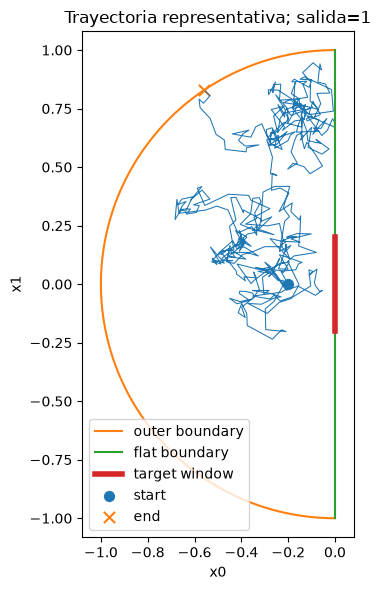

In [6]:
representative_case = BorderCase(
    dimension=2,
    epsilon=0.20,
    seed=BASE_SEED,
    max_steps=500_000,
)
delta_t = (
    (SPATIAL_RESOLUTION * representative_case.epsilon) ** 2
    / (2.0 * DIFFUSION)
)
initial = np.array([-representative_case.epsilon, 0.0])
motion = BrownianMotion(
    deposition_stride=100,
    delta_t=delta_t,
    dimension=2,
    D=DIFFUSION,
    initial_position=initial,
    seed=representative_case.seed,
)
solver = NaiveNarrowEscape(
    motion,
    half_ball_surface(),
    [target_window(representative_case.epsilon), outer_escape()],
)
representative = solver.run(max_steps=representative_case.max_steps)

path = representative.positions
fig, ax = plt.subplots(figsize=(6.6, 6.0))
stride = max(1, len(path) // 10_000)
ax.plot(path[::stride, 0], path[::stride, 1], linewidth=0.75)
theta = np.linspace(np.pi / 2.0, 3.0 * np.pi / 2.0, 500)
ax.plot(np.cos(theta), np.sin(theta), linewidth=1.5, label="outer boundary")
ax.plot(
    [0.0, 0.0],
    [-OUTER_RADIUS, OUTER_RADIUS],
    linewidth=1.5,
    label="flat boundary",
)
ax.plot(
    [0.0, 0.0],
    [-representative_case.epsilon, representative_case.epsilon],
    linewidth=4.0,
    label="target window",
)
ax.scatter(*path[0], s=50, label="start")
ax.scatter(*path[-1], marker="x", s=65, label="end")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.08, 0.08)
ax.set_ylim(-1.08, 1.08)
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title(
    f"Trayectoria representativa; salida={representative.escape_index}"
)
ax.legend()
finish_figure(fig, "representative_half_ball")

In [7]:
if RUN_MODE == "smoke":
    DIMENSIONS = [2, 3, 4]
    EPSILON_VALUES = np.array([0.35, 0.25, 0.18, 0.12])
    N_REPLICATES = 24
    MAX_STEPS = 350_000
else:
    DIMENSIONS = [2, 3, 4]
    EPSILON_VALUES = np.geomspace(0.45, 0.025, 12)
    N_REPLICATES = 500
    MAX_STEPS = 3_000_000

if RUN_MODE == "load":
    if not SUMMARY_PATH.exists():
        raise FileNotFoundError(f"No existe el caché {SUMMARY_PATH}.")
    runs = pd.read_csv(SUMMARY_PATH)
elif REUSE_CACHE and SUMMARY_PATH.exists():
    runs = pd.read_csv(SUMMARY_PATH)
else:
    n_tasks = len(DIMENSIONS) * len(EPSILON_VALUES) * N_REPLICATES
    seed_sequences = np.random.SeedSequence(BASE_SEED).spawn(n_tasks)
    tasks = []
    cursor = 0
    for dimension in DIMENSIONS:
        for epsilon in EPSILON_VALUES:
            for _ in range(N_REPLICATES):
                seed = int(seed_sequences[cursor].generate_state(1)[0])
                cursor += 1
                tasks.append(
                    BorderCase(
                        dimension=dimension,
                        epsilon=float(epsilon),
                        seed=seed,
                        max_steps=MAX_STEPS,
                    )
                )

    records = Parallel(n_jobs=N_JOBS)(
        delayed(run_border_case)(case) for case in tasks
    )
    runs = pd.DataFrame.from_records(records)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    runs.to_csv(SUMMARY_PATH, index=False)

runs.head()

,dimension,epsilon,delta_t,seed,escaped,escape_index,target_hit,outer_hit,escape_time,attempted_steps,rejected_steps
0,2,0.45,0.00405,1117257062,True,1,False,True,0.091595,23,0
1,2,0.45,0.00405,1739813875,True,0,True,False,0.111209,28,0
2,2,0.45,0.00405,1419349886,True,1,False,True,0.092255,23,0
3,2,0.45,0.00405,1077354921,True,1,False,True,0.177093,44,0
4,2,0.45,0.00405,1178390433,True,1,False,True,0.167469,42,0


In [8]:
summary_rows = []
for (dimension, epsilon), group in runs.groupby(["dimension", "epsilon"]):
    completed = group[group["escaped"]]
    successes = int(completed["target_hit"].sum())
    probability, lower, upper = wilson_interval(successes, len(completed))
    summary_rows.append(
        {
            "dimension": dimension,
            "epsilon": epsilon,
            "n_runs": len(group),
            "completion_rate": group["escaped"].mean(),
            "target_probability": probability,
            "ci95_lower": lower,
            "ci95_upper": upper,
            "mean_escape_time": completed["escape_time"].mean(),
            "mean_steps": group["attempted_steps"].mean(),
        }
    )

summary = pd.DataFrame(summary_rows).sort_values(["dimension", "epsilon"])
summary

,dimension,epsilon,n_runs,completion_rate,target_probability,ci95_lower,ci95_upper,mean_escape_time,mean_steps
0,2,0.025000,500,1.0,0.742,0.701906,0.778404,0.067589,5407.550
1,2,0.032513,500,1.0,0.744,0.703987,0.780292,0.061404,2904.850
2,2,0.042284,500,1.0,0.754,0.714408,0.789719,0.059839,1673.888
3,2,0.054990,500,1.0,0.722,0.681151,0.759463,0.067404,1114.940
4,2,0.071516,500,1.0,0.692,0.650198,0.730874,0.084396,825.494
5,2,0.093008,500,1.0,0.694,0.652255,0.732787,0.077660,449.310
6,2,0.120958,500,1.0,0.606,0.562518,0.647866,0.097038,332.036
7,2,0.157308,500,1.0,0.626,0.582779,0.667300,0.092580,187.490
8,2,0.204581,500,1.0,0.570,0.526234,0.612698,0.103654,124.248
9,2,0.266061,500,1.0,0.570,0.526234,0.612698,0.100417,71.342


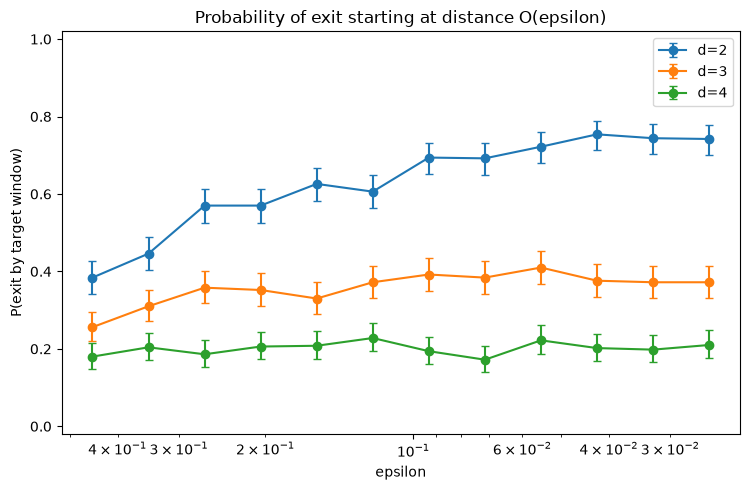

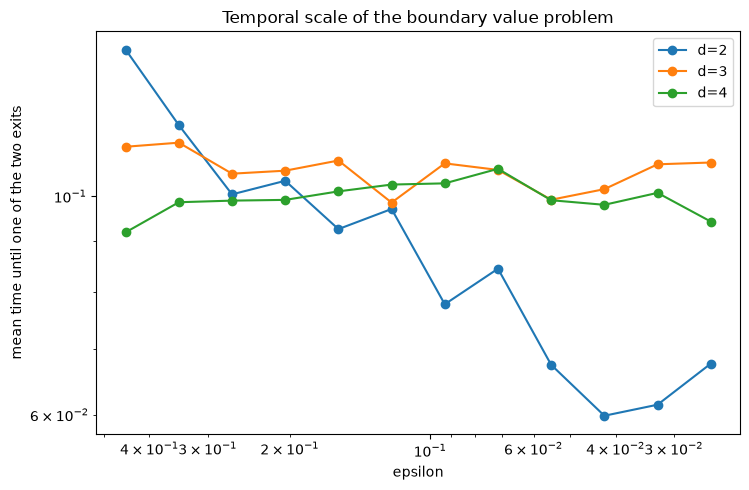

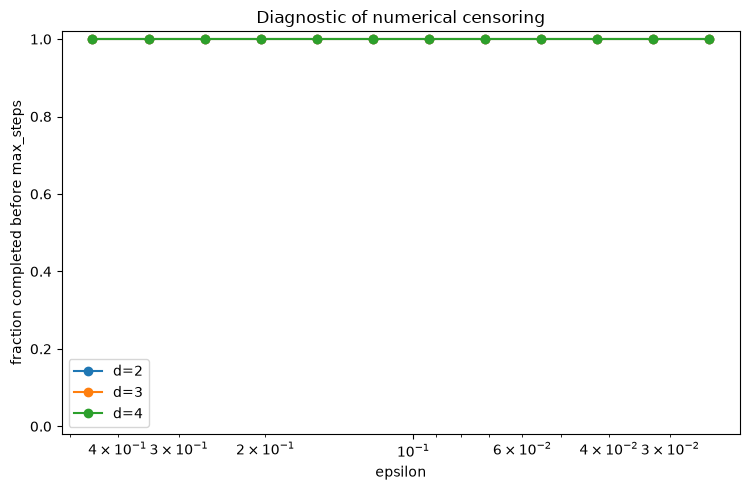

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 5.0))
for dimension, subset in summary.groupby("dimension"):
    subset = subset.sort_values("epsilon")
    yerr = np.vstack(
        [
            subset["target_probability"] - subset["ci95_lower"],
            subset["ci95_upper"] - subset["target_probability"],
        ]
    )
    ax.errorbar(
        subset["epsilon"],
        subset["target_probability"],
        yerr=yerr,
        marker="o",
        capsize=3,
        label=f"d={dimension}",
    )
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("epsilon")
ax.set_ylabel("P(exit by target window)")
ax.set_title("Probability of exit starting at distance O(epsilon)")
ax.legend()
finish_figure(fig, "probability_vs_epsilon")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for dimension, subset in summary.groupby("dimension"):
    subset = subset.sort_values("epsilon")
    ax.plot(
        subset["epsilon"],
        subset["mean_escape_time"],
        marker="o",
        label=f"d={dimension}",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("epsilon")
ax.set_ylabel("mean time until one of the two exits")
ax.set_title("Temporal scale of the boundary value problem")
ax.legend()
finish_figure(fig, "escape_time_vs_epsilon")

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for dimension, subset in summary.groupby("dimension"):
    subset = subset.sort_values("epsilon")
    ax.plot(
        subset["epsilon"],
        subset["completion_rate"],
        marker="o",
        label=f"d={dimension}",
    )
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("epsilon")
ax.set_ylabel("fraction completed before max_steps")
ax.set_title("Diagnostic of numerical censoring")
ax.legend()
finish_figure(fig, "completion_rate")